# Library imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import cartopy.crs as ccrs
from sklearn.metrics import r2_score
pd.set_option('display.float_format', lambda x: '%.2f' % x)
np.set_printoptions(suppress=True)

In [3]:
def find_coeffs(X, y):
    """
    Linear regression algorithm. 
    Input x = [x0,x1,x2,...,x_n], where x0 is a vector of ones (intercept bias of the regression)
    Input y = [y0,y1,y2,y_n] 
    Output beta = the weights of the linear regression model.
    """
    
    # The Normal Equation (closed form of the linear regression problem)
    beta = np.dot(np.linalg.inv(np.dot(X.T, X)), np.dot(X.T, y))
    
    return beta

# Dataset overview

In [4]:
gridded_atlantic_storms = pd.read_csv('gridded_atlantic_storms.csv')
gridded_atlantic_storms['year'] = pd.DatetimeIndex(gridded_atlantic_storms['date']).year
display(gridded_atlantic_storms.head(5))

grid_data = pd.read_csv('grid_data.csv')
nb_cells_grid = grid_data['grid_ids'].max()
display(grid_data.head(5))

,id,name,date,record_identifier,status_of_system,latitude,longitude,maximum_sustained_wind_knots,maximum_pressure,34_kt_ne,...,Int_ip1,SST_p1,ln_Int,ln_Int_im1,ln_Int_im2,ln_Int_ip1,delta_SST,pc_comp,grid_ids,year
0,AL011851,UNNAMED,1851-06-25 00:00:00,NaN,HU,28.00,-94.80,80,NaN,NaN,...,0.06,301.10,-2.87,NaN,NaN,-2.87,-0.07,974.27,70,1851
1,AL011851,UNNAMED,1851-06-25 06:00:00,NaN,HU,28.00,-95.40,80,NaN,NaN,...,0.06,301.03,-2.87,-2.87,NaN,-2.87,-0.07,974.27,69,1851
2,AL011851,UNNAMED,1851-06-25 12:00:00,NaN,HU,28.00,-96.00,80,NaN,NaN,...,0.06,300.98,-2.87,-2.87,-2.87,-2.87,-0.05,974.27,69,1851
3,AL011851,UNNAMED,1851-06-25 18:00:00,NaN,HU,28.10,-96.50,80,NaN,NaN,...,0.06,300.98,-2.87,-2.87,-2.87,-2.87,0.00,974.06,69,1851
4,AL011851,UNNAMED,1851-06-25 21:00:00,L,HU,28.20,-96.80,80,NaN,NaN,...,NaN,NaN,-2.87,-2.87,-2.87,NaN,NaN,974.24,69,1851


,grid_ids,longitude,latitude,record_per_cell,record_per_west_cell,record_per_east_cell,sufficient_records_west,sufficient_records_east
0,1,107.50,12.50,0,0,0,n,n
1,2,102.50,12.50,0,0,0,n,n
2,3,97.50,12.50,1,1,0,n,n
3,4,92.50,12.50,25,19,6,y,y
4,5,87.50,12.50,56,56,0,y,n


# Remove invalid inputs (artificial inputs or out of scope datasets)

In [5]:
# Remove the 1st values (their speed data is artificial) :
count = (gridded_atlantic_storms.groupby('id').cumcount())
gridded_atlantic_storms = gridded_atlantic_storms[(count !=0)]

# Drop the last value per storm (their speed variations are artificial) : 
gridded_atlantic_storms = gridded_atlantic_storms.drop(gridded_atlantic_storms.groupby('id').tail(1).index, axis = 0)

# Data clipping according to year :
min_year = 1850 # first year to exclude.
max_year = 2021 # year to start excluding.

edited_gridded_atlantic_storms = gridded_atlantic_storms[gridded_atlantic_storms.year > min_year]
edited_gridded_atlantic_storms = edited_gridded_atlantic_storms[edited_gridded_atlantic_storms.year < max_year]

# Splitting dataframes per grid id and heading

In [6]:
# Create a dictionary to compile all dataframes subsetted per cell id  
df_cell_id = {}
for ds in range(nb_cells_grid) :
    ds_in_grid = edited_gridded_atlantic_storms.loc[edited_gridded_atlantic_storms['grid_ids'] == ds+1]
    df_cell_id[ds+1] = pd.DataFrame(ds_in_grid)
    
# To get a quick look in table format: 
Visualize = False

if Visualize == True : 
    for ids, dataframe in df_cell_id.items() : 
        display(dataframe)

In [7]:
# Create a dictionary to compile all dataframes subsetted per cell id and direction (west versus east) : 
df = {}

for i in range(nb_cells_grid) : 
    ds_in_grid = edited_gridded_atlantic_storms.loc[edited_gridded_atlantic_storms['grid_ids'] == i+1]
    west_ds = ds_in_grid[ds_in_grid['E_or_W']== 'W']
    east_ds = ds_in_grid[ds_in_grid['E_or_W']== 'E']

    df[f'W{i+1}'] = pd.DataFrame(west_ds)
    df[f'E{i+1}'] = pd.DataFrame(east_ds)

# To get a quick look in table format: 
Visualize = False

if Visualize == True : 
    for ids, dataframe in df.items() : 
        display(dataframe)

# Coefficient fitting and modeling errors : 

## Translation & heading coefficients :

Plotting the translation graphs for cell W95.
R2-score: 0.65


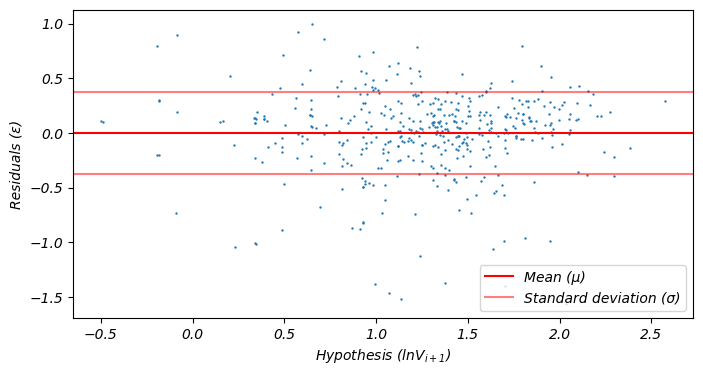

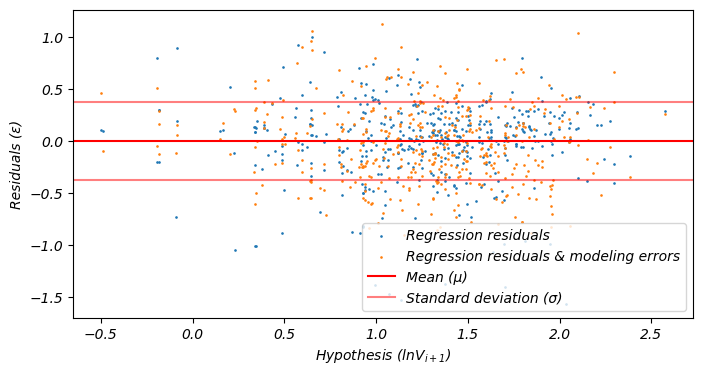

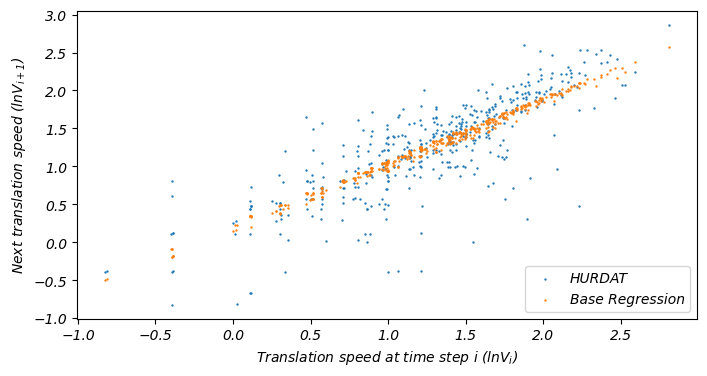

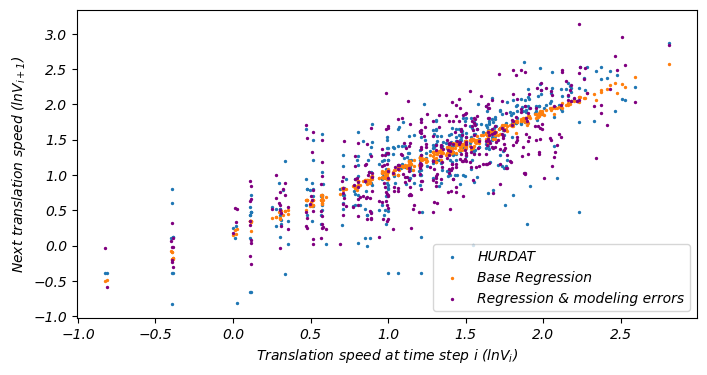

Mu : 0.00 and std 0.37
Mu : -0.02 and std 0.38
Plotting the heading graphs for cell W95.
R2-score: 0.03


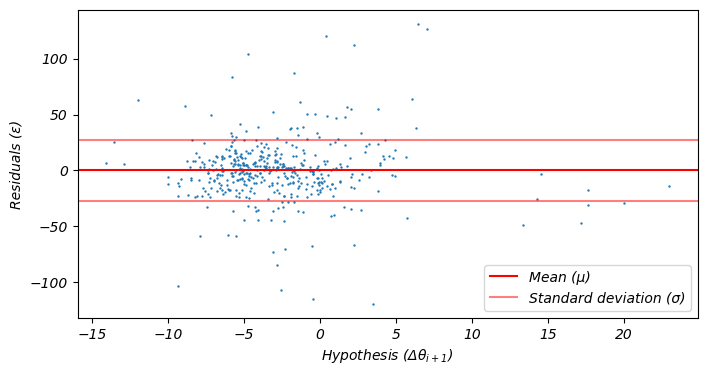

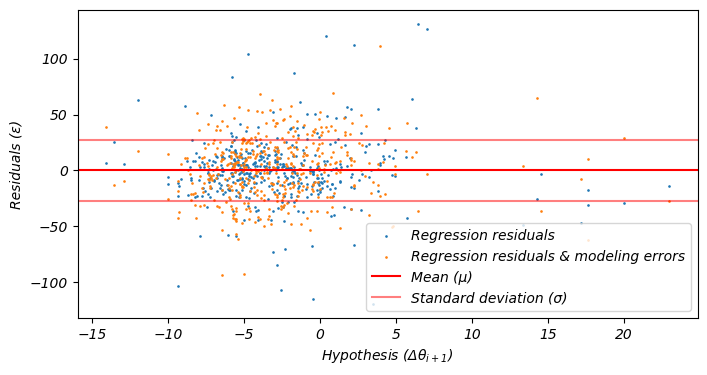

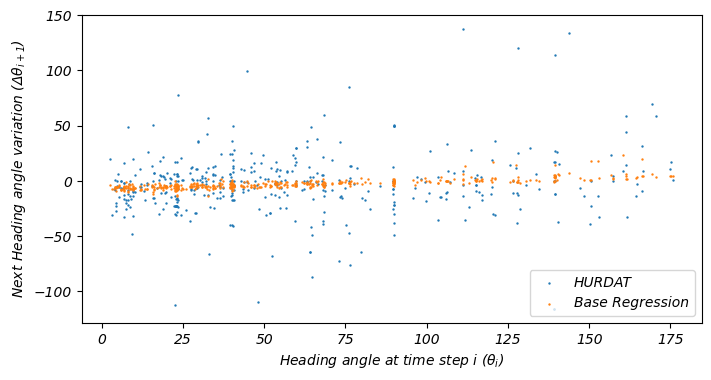

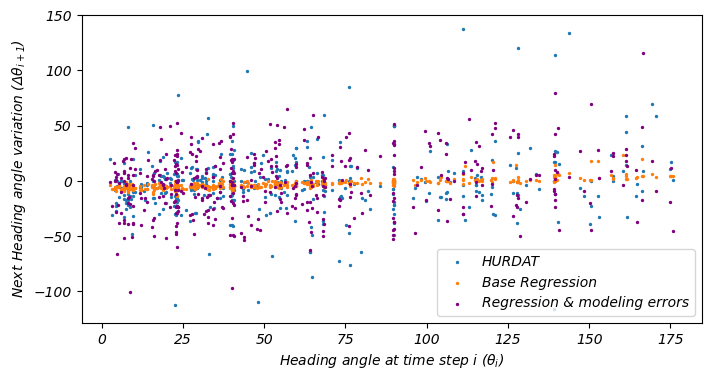

In [8]:
Coeffs_E = []
Coeffs_W = []

for key in list(df.keys()) :   
    Heading = key[0]
    grid_id = key[1:]   
    grid_look_up = Heading+grid_id

    if Heading == 'E' : 
        # Liu 2014 recommands not to perform regressions on cells with less than 6 datasets : 
        if df[grid_look_up].shape[0] >= 6 : 
            #---------------------------------------------------------
            # Extract the base coefficients for the translation speed model : 
            # The known target outputs : 
            y = np.asanyarray(df[grid_look_up]['ln_Vip1'])

            # Snaiki and Wu (2020) suggest a regression with 5 coefficients for translation in eastward cells : 
            # The features : 
            x_0 = np.ones([df[grid_look_up].shape[0],1]) # x0 + formatting the array
            #x1 = df['Ei']['ln_V']        # x1 = ln(c_i)  = translation speed
            #x2 = df['Ei']['latitude']    # x2 = phi_i    = latitude
            #x3 = df['Ei']['longitude']   # x3 = lambda_i = longitude
            #x4 = df['Ei']['theta']       # x4 = theta_i  = heading angle

            # Lets just acquire everything in one go : 
            x = np.asanyarray(df[grid_look_up][['ln_V','latitude','longitude','theta']])

            # Assemble the features : 
            X = np.concatenate((x_0,x), axis =1)

            # Find the regression coefficients :
            alpha = find_coeffs(X,y)
            
            # Error residuals :
            y_hat_tr =np.matmul(X,alpha)
            residuals_translation = y-y_hat_tr
            mean_res_tr = np.mean(residuals_translation)
            std_res_tr = np.std(residuals_translation, ddof = 1)
 

            # Linear transformations on the student T distribution for the residuals: 
            # Main parameters required to model the residuals : 
            dgr_of_frdm_tr = y_hat_tr.shape[0]-1
            residuals_tr = (dgr_of_frdm_tr,std_res_tr)
            
            # To simulate the residuals : 
            # student_residuals_tr = np.random.default_rng().standard_t(dgr_of_frdm_tr, size=y_hat_tr.shape[0])*std_res_tr
            # y_hat_e_tr = y_hat_tr+student_residuals_tr
            # new_residuals_tr = y_hat_e_tr-y_hat_tr   
            
            # Group the regression coefficients with the residuals main parameters : 
            alpha_coeffs_tr = []
            alpha_coeffs_tr.append(tuple(alpha))
            alpha_coeffs_tr.append(residuals_tr)
        
            #-------------------------------------------------------            
            # Extract the base coefficients for the heading model : 
            # The known target output : 
            yH = np.asanyarray(df[grid_look_up]['delta_theta_v2'])
            
            # Snaiki and Wu (2020) suggest a regression with 6 coefficients for heading :
            # The features : 
            xH_0 = np.ones([df[grid_look_up].shape[0],1]) # x0 + formatting the array
            #xH_1 = df['Ei']['latitude']    # x1 = phi_i      = latitude
            #xH_2 = df['Ei']['longitude']   # x2 = lambda_i   = longitude
            #xH_3 = df['Ei']['Vi']          # x3 = c_i        = translation speed
            #xH_4 = df['Ei']['theta']       # x4 = theta_i    = heading angle            
            #xH_5 = df['Ei']['theta_im1']   # x5 = theta_ip1  = heading angle at previous time step            
            
            # Lets just acquire everything in one go : 
            xH = np.asanyarray(df[grid_look_up][['latitude','longitude','Vi','theta','theta_im1']])

            # Assemble the features : 
            XH = np.concatenate((xH_0,xH), axis =1)            
            
            # Find the regression coefficients :
            beta = find_coeffs(XH,yH)
            
            # Error residuals : 
            y_hat_H =np.matmul(XH,beta)
            residuals_heading = yH-y_hat_H
            mean_res_H = np.mean(residuals_heading)
            std_res_H = np.std(residuals_heading, ddof = 1)   
            
            # Linear transformations on the student T distribution for the residuals: 
            # Main parameters required to model the residuals : 
            dgr_of_frdm_H = y_hat_H.shape[0]-1
            residuals_H = (dgr_of_frdm_H,std_res_H)         
            
            # To simulate the residuals : 
            # student_residuals_H = np.random.default_rng().standard_t(dgr_of_frdm_H, size=sample_size_H)*std_res_H
            # y_hat_e_H = y_hat_H+student_residuals_H
            # new_residuals_H = y_hat_e_H-y_hat_H              
            
            # Group the regression coefficients with the residuals main parameters : 
            beta_coeffs_tr = []
            beta_coeffs_tr.append(tuple(beta))
            beta_coeffs_tr.append(residuals_H)

            #-----------------------------------------------------            
            # Associate to corresponding grid :  
            Coeffs_E.append([int(grid_id),alpha_coeffs_tr,beta_coeffs_tr])                      
        else : 
            Coeffs_E.append([int(grid_id),np.nan,np.nan])
            
    elif Heading == 'W' :
        # Liu 2014 recommands not to perform regressions on cells with less than 6 datasets :
        if df[grid_look_up].shape[0] >= 6 :         
            #---------------------------------------------------------
            # Extract the base coefficients for the regression model : 
            # The known target outputs : 
            y = np.asanyarray(df[grid_look_up]['ln_Vip1'])

            x_0 = np.ones([df[grid_look_up].shape[0],1]) # x0 + formatting the array
            #x1 = df['Wi']['ln_V']        # x1 = ln(c_i)  = translation speed
            #x2 = df['Wi']['latitude']    # x2 = phi_i    = latitude
            #x3 = df['Wi']['longitude']   # x3 = lambda_i = longitude
            #x4 = df['Wi']['theta']       # x4 = theta_i  = heading angle

            # Lets just acquire everything in one go : 
            x = np.asanyarray(df[grid_look_up][['ln_V','latitude','longitude','theta']])
            
            # Assemble the features : 
            X = np.concatenate((x_0,x), axis =1)

            # Find the regression coefficients :
            alpha = find_coeffs(X,y)

            # Error residuals :
            y_hat_tr =np.matmul(X,alpha)
            residuals_translation = y-y_hat_tr
            mean_res_tr = np.mean(residuals_translation)
            std_res_tr = np.std(residuals_translation, ddof = 1)


            # Linear transformations on the student T distribution for the residuals: 
            # Main parameters required to model the residuals : 
            dgr_of_frdm_tr = y_hat_tr.shape[0]-1
            residuals_tr = (dgr_of_frdm_tr,std_res_tr)       
            
            # To simulate the residuals : 
            # student_residuals_tr = np.random.default_rng().standard_t(dgr_of_frdm_tr, size=sample_size_tr)*std_res_tr
            # y_hat_e_tr = y_hat_tr+student_residuals_tr
            # new_residuals_tr = y_hat_e_tr-y_hat_tr 
            
            # Group the regression coefficients with the residuals main parameters : 
            alpha_coeffs_tr = []
            alpha_coeffs_tr.append(tuple(alpha))
            alpha_coeffs_tr.append(residuals_tr)
            
            #-------------------------------------------------------
            # Extract the base coefficients for the heading model : 
            # The known target output : 
            yH = np.asanyarray(df[grid_look_up]['delta_theta_v2'])
            
            # Snaiki and Wu (2020) suggest a regression with 6 coefficients for heading :
            # The features : 
            xH_0 = np.ones([df[grid_look_up].shape[0],1]) # x0 + formatting the array
            #xH_1 = df['Wi']['latitude']    # x1 = phi_i      = latitude
            #xH_2 = df['Wi']['longitude']   # x2 = lambda_i   = longitude
            #xH_3 = df['Wi']['Vi']          # x3 = c_i        = translation speed
            #xH_4 = df['Wi']['theta']       # x4 = theta_i    = heading angle            
            #xH_5 = df['Wi']['theta_im1']   # x5 = theta_ip1  = heading angle at previous time step            
            
            # Lets just acquire everything in one go : 
            xH = np.asanyarray(df[grid_look_up][['latitude','longitude','Vi','theta','theta_im1']])

            # Assemble the features : 
            XH = np.concatenate((xH_0,xH), axis =1)            
            
            # Find the regression coefficients :
            beta = find_coeffs(XH,yH)
            
            # Error residuals : 
            y_hat_H =np.matmul(XH,beta)
            residuals_heading = yH-y_hat_H  
            mean_res_H = np.mean(residuals_heading)
            std_res_H = np.std(residuals_heading, ddof = 1)
            
            # Linear transformations on the student T distribution for the residuals: 
            # Main parameters required to model the residuals : 
            dgr_of_frdm_H = y_hat_H.shape[0]-1
            residuals_H = (dgr_of_frdm_H,std_res_H)          
            
            # To simulate the residuals : 
            # student_residuals_H = np.random.default_rng().standard_t(dgr_of_frdm_H, size=sample_size_H)*std_res_H
            # y_hat_e_H = y_hat_H+student_residuals_H
            # new_residuals_H = y_hat_e_H-y_hat_H
            
            # Group the regression coefficients with the residuals main parameters : 
            beta_coeffs_tr = []
            beta_coeffs_tr.append(tuple(beta))
            beta_coeffs_tr.append(residuals_H)
            
            #-----------------------------------------------------
            # Associate to corresponding grid : 
            Coeffs_W.append([int(grid_id),alpha_coeffs_tr,beta_coeffs_tr]) 
                       
        else : 
            Coeffs_W.append([int(grid_id),np.nan,np.nan])
            
    Plot_one = True
    Plot_translation = True
    Plot_heading = True
        
    if grid_look_up == 'W95' and Plot_one == True : 
      
        # If the mean is 0, either a Johnson, Normal or Student distribution can be investigated to take residuals
        # into account.
        
        # Residuals with multiple predictors (x is of higher dimension than 2) are usualy plotted against y_hat instead.
        
        if Plot_translation == True :
            print(f'Plotting the translation graphs for cell {grid_look_up}.')
            print("R2-score: %.2f" % r2_score(y , y_hat_tr) )

            student_residuals_tr = np.random.default_rng().standard_t(y_hat_tr.shape[0]-1, size=y_hat_tr.shape[0])*std_res_tr
            y_hat_e_tr = y_hat_tr+student_residuals_tr
            new_residuals_tr = y_hat_e_tr-y_hat_tr
            mean_res_tr_n = np.mean(new_residuals_tr)
            std_res_tr_n = np.std(new_residuals_tr, ddof = 1) 
        
        
            fig = plt.figure(figsize=(8,4))
            plt.scatter(y_hat_tr,residuals_translation,
                s = 0.5,
                label = '',
               )
            plt.axhline(y=mean_res_tr, color='r', linestyle='-', label = 'Mean (\u03BC)')
            plt.axhline(y=mean_res_tr+std_res_tr, color='red', linestyle='-', alpha = 0.5, label = 'Standard deviation (\u03C3)')
            plt.axhline(y=mean_res_tr-std_res_tr, color='red', linestyle='-',alpha = 0.5)
            plt.legend(loc = 'lower right')
            plt.xlabel('Hypothesis ($ln V_{i+1}$)')
            plt.ylabel('Residuals (\u03B5)')      
        
            fig4 = plt.figure(figsize=(8,4))
            plt.scatter(y_hat_tr,residuals_translation,
                s = 0.8,
                label = 'Regression residuals',
               )
            plt.scatter(y_hat_tr,new_residuals_tr,
                s = 0.8,
                label = 'Regression residuals & modeling errors',
               )
            plt.axhline(y=mean_res_tr, color='r', linestyle='-', label = 'Mean (\u03BC)')
            plt.axhline(y=mean_res_tr+std_res_tr, color='red', linestyle='-', alpha = 0.5, label = 'Standard deviation (\u03C3)')
            plt.axhline(y=mean_res_tr-std_res_tr, color='red', linestyle='-',alpha = 0.5)
            plt.legend(loc = 'lower right')
            plt.xlabel('Hypothesis ($ln V_{i+1}$)')
            plt.ylabel('Residuals (\u03B5)') 

            # Lets see the predictions without the residuals :        
            ln_Vti = np.asanyarray(df[grid_look_up][['ln_V']])
        
            fig2 = plt.figure(figsize = (8,4))
            plt.scatter(ln_Vti,y,
                s = 0.5,
                label = 'HURDAT',
                )

            plt.scatter(ln_Vti,y_hat_tr,
                s = 0.5,
                label = 'Base Regression',
                )
            plt.legend(loc = 'lower right')
            plt.xlabel('Translation speed at time step i ($ln V_{i}$)')
            plt.ylabel('Next translation speed ($ln V_{i+1}$)')        
        
            # Adding modeling errors : 
            fig3 = plt.figure(figsize = (8,4))
            plt.scatter(ln_Vti,y,
                s = 2.0,
                label = 'HURDAT',
                #color = 'blue',
                marker = 'o'
                )

            plt.scatter(ln_Vti,y_hat_tr,
                s = 2.0,
                label = 'Base Regression',
                #color = 'darkorange',
                marker = 'o'
                )
        
            plt.scatter(ln_Vti,y_hat_e_tr,
                s = 2,
                label = 'Regression & modeling errors',
                color = 'purple'
                )
        
            plt.legend(loc = 'lower right')
            plt.xlabel('Translation speed at time step i ($ln V_{i}$)')
            plt.ylabel('Next translation speed ($ln V_{i+1}$)')
            plt.show()        

        
            print(f'Mu : {mean_res_tr:.2f} and std {std_res_tr:.2f}')
            print(f'Mu : {mean_res_tr_n:.2f} and std {std_res_tr_n:.2f}')        
 

        if Plot_heading == True :
            print(f'Plotting the heading graphs for cell {grid_look_up}.')
            print("R2-score: %.2f" % r2_score(yH , y_hat_H) )
            
            student_residuals_H = np.random.default_rng().standard_t(y_hat_H.shape[0]-1, size=y_hat_H.shape[0])*std_res_H
            y_hat_e_H = y_hat_H+student_residuals_H
            new_residuals_H = y_hat_e_H-y_hat_H
            mean_res_H_n = np.mean(new_residuals_H)
            std_res_H_n = np.std(new_residuals_H, ddof = 1)             
        

            fig5 = plt.figure(figsize=(8,4))
            plt.scatter(y_hat_H,residuals_heading,
                s = 0.5,
                label = '',
               )
            plt.axhline(y=mean_res_H, color='r', linestyle='-', label = 'Mean (\u03BC)')
            plt.axhline(y=mean_res_H+std_res_H, color='red', linestyle='-', alpha = 0.5, label = 'Standard deviation (\u03C3)')
            plt.axhline(y=mean_res_H-std_res_H, color='red', linestyle='-',alpha = 0.5)
            plt.legend(loc = 'lower right')
            plt.xlabel('Hypothesis ($\u0394 \u03B8_{i+1}$)')
            plt.ylabel('Residuals (\u03B5)')        
        
            fig6 = plt.figure(figsize=(8,4))
            plt.scatter(y_hat_H,residuals_heading,
                s = 0.8,
                label = 'Regression residuals',
               )
            plt.scatter(y_hat_H,new_residuals_H,
                s = 0.8,
                label = 'Regression residuals & modeling errors',
               )
            plt.axhline(y=mean_res_H, color='r', linestyle='-', label = 'Mean (\u03BC)')
            plt.axhline(y=mean_res_H+std_res_H, color='red', linestyle='-', alpha = 0.5, label = 'Standard deviation (\u03C3)')
            plt.axhline(y=mean_res_H-std_res_H, color='red', linestyle='-',alpha = 0.5)
            plt.legend(loc = 'lower right')
            plt.xlabel('Hypothesis ($\u0394 \u03B8_{i+1}$)')
            plt.ylabel('Residuals (\u03B5)') 
        
            # Lets see the predictions without the residuals :        
            theta_i = np.asanyarray(df[grid_look_up][['theta']])
        
            fig7 = plt.figure(figsize = (8,4))
            plt.scatter(theta_i,yH,
                s = 0.5,
                label = 'HURDAT',
                )

            plt.scatter(theta_i,y_hat_H,
                s = 0.5,
                label = 'Base Regression',
                )
            plt.legend(loc = 'lower right')
            plt.xlabel('Heading angle at time step i ($\u03B8_{i}$)')
            plt.ylabel('Next Heading angle variation ($\u0394 \u03B8_{i+1}$)')

            # Adding modeling errors : 
            fig8 = plt.figure(figsize = (8,4))
            plt.scatter(theta_i,yH,
                s = 2.0,
                label = 'HURDAT',
                #color = 'blue',
                marker = 'o'
                )

            plt.scatter(theta_i,y_hat_H,
                s = 2.0,
                label = 'Base Regression',
                #color = 'darkorange',
                marker = 'o'
                )
        
            plt.scatter(theta_i,y_hat_e_H,
                s = 2,
                label = 'Regression & modeling errors',
                color = 'purple'
                )
        
            plt.legend(loc = 'lower right')
            plt.xlabel('Heading angle at time step i ($\u03B8_{i}$)')
            plt.ylabel('Next Heading angle variation ($\u0394 \u03B8_{i+1}$)')       
            plt.show()        
        
W_coeffs_df = pd.DataFrame(Coeffs_W,columns = ['grid_ids', 'alpha_coeffs', 'beta_coeffs']).sort_values(by = 'grid_ids')
grid_data['W_alpha_coeffs'] = W_coeffs_df['alpha_coeffs']
grid_data['W_beta_coeffs'] = W_coeffs_df['beta_coeffs']


E_coeffs_df = pd.DataFrame(Coeffs_E,columns = ['grid_ids', 'alpha_coeffs','beta_coeffs']).sort_values(by = 'grid_ids')
grid_data['E_alpha_coeffs'] = E_coeffs_df['alpha_coeffs']
grid_data['E_beta_coeffs'] = E_coeffs_df['beta_coeffs']


#---------------------------------------------------------
# Validations : 

#display(grid_data)
# Accessing the coefficients in one cell : 
# grid_data.iloc[3,:]['E_alpha_coeffs']
# Accessing a specific coefficient :
# grid_data.iloc[3,:]['E_alpha_coeffs'][1][0]

## Performing predictions (relying on the grid_data df)

In [9]:
# Extract the values to perform predictions : 
#alpha_coeffs = np.asanyarray(df_cell_id[74]['W_alpha_coeffs'].iloc[0])
#eps_tr = np.asanyarray(df_cell_id[74]['W_eps_tr_inputs'].iloc[0])

# The regression values :
#test_y_hat_tr=np.matmul(test_x,alpha_coeffs)
#simul_resid = np.random.default_rng().standard_t(int(eps_tr[0]), size=int(eps_tr[0]+1))*eps_tr[1]
# simul_values = test_y_hat_tr + simul_resid

## Handling cells with less than 6 data points in a given direction

In [10]:
# Review the grid system : 
# Longitude :
min_lat = 10 # degree
max_lat = 60 # degree
lat_grids = 5 # degree

# Latitude : 
min_long = 0 # degree
max_long = 110 # degree
long_grids = 5 # degree

# Grid info
grid_width = max_long-min_long
grid_height = max_lat-min_lat
nb_width_cell = int(grid_width/long_grids)
nb_height_cell = int(grid_height/lat_grids)
nb_cells = int((nb_width_cell)*(nb_height_cell))

In [11]:
# Grid geometry 
first_row_max = nb_width_cell
final_row_min = nb_cells - nb_width_cell+1
row_ends = np.arange(0,nb_cells+1,nb_width_cell)


# Make a dataframe with the coefficients 
df_init = pd.DataFrame(grid_data[['grid_ids','E_alpha_coeffs','E_beta_coeffs','W_alpha_coeffs','W_beta_coeffs']])

# Allocate a row id for each grid cell values : 
corr_grid_row = []
for value in df_init['grid_ids'] : 
    corr_grid_row.append(np.digitize(value,row_ends, right = True))
df_init['grid_row_id'] =corr_grid_row
df_init2 = df_init.copy()
display(df_init2)

# Group the dataframe per rows (so that iterations in next cells only span the grid rows): 
df_init = df_init.groupby('grid_row_id')

,grid_ids,E_alpha_coeffs,E_beta_coeffs,W_alpha_coeffs,W_beta_coeffs,grid_row_id
0,1,NaN,NaN,NaN,NaN,1
1,2,NaN,NaN,NaN,NaN,1
2,3,NaN,NaN,NaN,NaN,1
3,4,"[(781.1682535056025, 0.45729229192147614, -0.7...","[(540938.0758666992, 1005.0017541646957, 6143....","[(4.183174132303066, 0.9780265321125654, 0.111...","[(22.31406519614029, 5.649775028162566, 1.2457...",1
4,5,NaN,NaN,"[(0.7860770944771502, 0.9550862831322746, 0.03...","[(115.77908584475517, -1.3330109702169892, 1.2...",1
...,...,...,...,...,...,...
215,216,"[(5.095994105457066, 0.4432276114450815, -0.10...","[(88.06690347758376, -0.6124328368944418, 3.91...",NaN,NaN,10
216,217,"[(3.295065665115544, 0.8374441487617048, -0.03...","[(514.3999672405334, -11.814746803032875, -12....",NaN,NaN,10
217,218,"[(1.1095730869865292, 0.9748759911496094, -0.0...","[(115.92331345791763, -3.325830622047423, -2.3...",NaN,NaN,10
218,219,"[(0.007788529444951564, 0.5603868122289732, 0....","[(408.68141897474675, -7.042085487747828, -1.3...",NaN,NaN,10


### Eastward grids

In [12]:
#Rounds of modifications require lists to store the values : 
# Eastern translation coeffs :
final_ETR_coeffs = []
final_ETR_coeffs2 = []
# Eastern Heading coeffs :
final_EH_coeffs = []
final_EH_coeffs2 = []

#-------------------------------------------------------------
#   Special Edits 

# Row id if a visual check is desired : 
control_id = 0  # 0 = no check at all. 

# Row 1 special edits start at : 
row1_grid_start = 9
# Final row special edits start at : 
row_n_grid_mod = 13
#-------------------------------------------------------------
# Start iterating the grid ids : 

# Select the row groups :
for row_id, item in df_init :    
    #------------------------------------------------------------------
    # We'll do minimal modifications to the first row group - it requires special handling :
    if row_id == 1 :       
        # Take the neighboring cells on the right as the fill values :   
        item.loc[0:row1_grid_start,'E_alpha_coeffs'] = item.loc[0:row1_grid_start,'E_alpha_coeffs'].fillna(method = 'bfill')
        final_ETR_coeffs.extend(item['E_alpha_coeffs'])
        
        item.loc[0:row1_grid_start,'E_beta_coeffs'] = item.loc[0:row1_grid_start,'E_beta_coeffs'].fillna(method = 'bfill')
        final_EH_coeffs.extend(item['E_beta_coeffs'])           
    #------------------------------------------------------------------    
    # We'll do minimal modifications to the final row group - it requires special handling :
    if row_id == row_ends.shape[0]-1 :
        item.loc[nb_cells-row_n_grid_mod:nb_cells+1,'E_alpha_coeffs'] = item.loc[nb_cells-row_n_grid_mod:nb_cells+1,'E_alpha_coeffs'].fillna(method = 'bfill')
        item.loc[nb_cells-row_n_grid_mod:nb_cells+1,'E_alpha_coeffs'] = item.loc[nb_cells-row_n_grid_mod:nb_cells+1,'E_alpha_coeffs'].fillna(method = 'ffill')
        final_ETR_coeffs.extend(item['E_alpha_coeffs'])  
        
        item.loc[nb_cells-row_n_grid_mod:nb_cells+1,'E_beta_coeffs'] = item.loc[nb_cells-row_n_grid_mod:nb_cells+1,'E_beta_coeffs'].fillna(method = 'bfill')
        item.loc[nb_cells-row_n_grid_mod:nb_cells+1,'E_beta_coeffs'] = item.loc[nb_cells-row_n_grid_mod:nb_cells+1,'E_beta_coeffs'].fillna(method = 'ffill')
        final_EH_coeffs.extend(item['E_beta_coeffs'])         
    #------------------------------------------------------------------    
    # Unique strategy : look right, then left! 
    if 1 < row_id < row_ends.shape[0]-1 :
        
        # Screenshot of "before" : 
        if row_id == control_id : 
            display(item)
        
        # Take the neighboring cells on the right as the fill values : 
        item['E_alpha_coeffs'].fillna(method = 'bfill',inplace = True)
        # Take the neighboring cells on the left as the fill values for the remaining cells : 
        item['E_alpha_coeffs'].fillna(method = 'ffill',inplace = True)        
        
        final_ETR_coeffs.extend(item['E_alpha_coeffs'])
        
        # Take the neighboring cells on the right as the fill values : 
        item['E_beta_coeffs'].fillna(method = 'bfill',inplace = True)
        # Take the neighboring cells on the left as the fill values for the remaining cells : 
        item['E_beta_coeffs'].fillna(method = 'ffill',inplace = True)        
        
        final_EH_coeffs.extend(item['E_beta_coeffs'])        
            
        # Screenshot of "after" : 
        if row_id == control_id : 
            display(item)

# End of first pass : 
df_init2['E_alpha_coeffs_ed'] = final_ETR_coeffs
df_init2['E_beta_coeffs_ed'] = final_EH_coeffs
#--------------------------------------------------------------------------------------------
# 2nd pass : this time, we take care of the remaining rows which require specific attention : 
# 2nd pass required because some of the overwritten values of 1st pass are required to perform next modifications : 
df_init3 = df_init2.copy()
df_init3 = df_init3.groupby('grid_row_id')

# Iterate the groups : 
for row_id, item in df_init3 :    
    #------------------------------------------------------------------
    # We'll do the final modifications on row 1 :
    if row_id == 1 :
        # If row_id == 1, we need to go search the row ABOVE for the values, thus : 
        target_item = df_init3.get_group(row_id+1)
        
        # We aim to change :
        item.loc[row1_grid_start:nb_width_cell+1,'E_alpha_coeffs_ed'] = np.where(
            # With the condition that :
            item.loc[row1_grid_start:nb_width_cell+1,'E_alpha_coeffs_ed'].isna(),
            # If true :
            target_item.loc[row1_grid_start+nb_width_cell:(nb_width_cell+nb_width_cell),'E_alpha_coeffs_ed'],
            # If false :
            item.loc[row1_grid_start:nb_width_cell+1,'E_alpha_coeffs_ed']
        )        
        final_ETR_coeffs2.extend(item['E_alpha_coeffs_ed'])     
        
        # We aim to change :        
        item.loc[row1_grid_start:nb_width_cell+1,'E_beta_coeffs_ed'] = np.where(
            # With the condition that :
            item.loc[row1_grid_start:nb_width_cell+1,'E_beta_coeffs_ed'].isna(),
            # If true :
            target_item.loc[row1_grid_start+nb_width_cell:(nb_width_cell+nb_width_cell),'E_beta_coeffs_ed'],
            # If false :
            item.loc[row1_grid_start:nb_width_cell+1,'E_beta_coeffs_ed']
        ) 
        final_EH_coeffs2.extend(item['E_beta_coeffs_ed'])           
    #------------------------------------------------------------------
    if row_id == row_ends.shape[0]-1 :
        # If row_id == 10, we need to go search the row BELOW for the values, thus : 
        target_item = df_init3.get_group(row_id-1)        
        
        # We aim to change :
        item.loc[nb_cells-nb_width_cell:nb_cells-row_n_grid_mod-1,'E_alpha_coeffs_ed'] = np.where(        
            # With the condition that :
            item.loc[nb_cells-nb_width_cell:nb_cells-row_n_grid_mod-1,'E_alpha_coeffs_ed'].isna(),
            # If true :
            target_item.loc[nb_cells-nb_width_cell-nb_width_cell:(nb_cells-row_n_grid_mod-1-nb_width_cell),'E_alpha_coeffs_ed'],
            # If false :
            item.loc[nb_cells-nb_width_cell:nb_cells-row_n_grid_mod-1,'E_alpha_coeffs_ed']
        )              
        final_ETR_coeffs2.extend(item['E_alpha_coeffs_ed']) 
        
        # We aim to change :        
        item.loc[nb_cells-nb_width_cell:nb_cells-row_n_grid_mod-1,'E_beta_coeffs_ed'] = np.where(        
            # With the condition that :
            item.loc[nb_cells-nb_width_cell:nb_cells-row_n_grid_mod-1,'E_beta_coeffs_ed'].isna(),
            # If true :
            target_item.loc[nb_cells-nb_width_cell-nb_width_cell:(nb_cells-row_n_grid_mod-1-nb_width_cell),'E_beta_coeffs_ed'],
            # If false :
            item.loc[nb_cells-nb_width_cell:nb_cells-row_n_grid_mod-1,'E_beta_coeffs_ed']
        )        
        final_EH_coeffs2.extend(item['E_beta_coeffs_ed'])                
    #------------------------------------------------------------------
    if 1 < row_id < row_ends.shape[0]-1 :            
        final_ETR_coeffs2.extend(item['E_alpha_coeffs_ed'])
        final_EH_coeffs2.extend(item['E_beta_coeffs_ed'])
        
df_init2['E_alpha_coeffs_ed2'] = final_ETR_coeffs2        
df_init2['E_beta_coeffs_ed2'] = final_EH_coeffs2   

# Looking at values at begining and end (if desired) : 
display_ends = True 

if display_ends == True : 
    display(df_init2.head(25))    
    display(df_init2.tail(25))   

,grid_ids,E_alpha_coeffs,E_beta_coeffs,W_alpha_coeffs,W_beta_coeffs,grid_row_id,E_alpha_coeffs_ed,E_beta_coeffs_ed,E_alpha_coeffs_ed2,E_beta_coeffs_ed2
0,1,NaN,NaN,NaN,NaN,1,"[(781.1682535056025, 0.45729229192147614, -0.7...","[(540938.0758666992, 1005.0017541646957, 6143....","[(781.1682535056025, 0.45729229192147614, -0.7...","[(540938.0758666992, 1005.0017541646957, 6143...."
1,2,NaN,NaN,NaN,NaN,1,"[(781.1682535056025, 0.45729229192147614, -0.7...","[(540938.0758666992, 1005.0017541646957, 6143....","[(781.1682535056025, 0.45729229192147614, -0.7...","[(540938.0758666992, 1005.0017541646957, 6143...."
2,3,NaN,NaN,NaN,NaN,1,"[(781.1682535056025, 0.45729229192147614, -0.7...","[(540938.0758666992, 1005.0017541646957, 6143....","[(781.1682535056025, 0.45729229192147614, -0.7...","[(540938.0758666992, 1005.0017541646957, 6143...."
3,4,"[(781.1682535056025, 0.45729229192147614, -0.7...","[(540938.0758666992, 1005.0017541646957, 6143....","[(4.183174132303066, 0.9780265321125654, 0.111...","[(22.31406519614029, 5.649775028162566, 1.2457...",1,"[(781.1682535056025, 0.45729229192147614, -0.7...","[(540938.0758666992, 1005.0017541646957, 6143....","[(781.1682535056025, 0.45729229192147614, -0.7...","[(540938.0758666992, 1005.0017541646957, 6143...."
4,5,NaN,NaN,"[(0.7860770944771502, 0.9550862831322746, 0.03...","[(115.77908584475517, -1.3330109702169892, 1.2...",1,"[(-2.649725156294153, 0.8829161186806935, 0.04...","[(-332.59685801367596, 0.010390189105976333, -...","[(-2.649725156294153, 0.8829161186806935, 0.04...","[(-332.59685801367596, 0.010390189105976333, -..."
5,6,"[(-2.649725156294153, 0.8829161186806935, 0.04...","[(-332.59685801367596, 0.010390189105976333, -...","[(-0.5150520883707941, 0.8533642547465838, 0.0...","[(-73.32086111720491, 1.3401025016128223, -0.6...",1,"[(-2.649725156294153, 0.8829161186806935, 0.04...","[(-332.59685801367596, 0.010390189105976333, -...","[(-2.649725156294153, 0.8829161186806935, 0.04...","[(-332.59685801367596, 0.010390189105976333, -..."
6,7,"[(0.042141750483096985, 0.8359191827250392, 0....","[(115.41889468104637, -1.2250402624553942, 1.1...","[(1.9099593661812833, 0.9164353928860152, -0.0...","[(-75.67190239114461, -1.1453177416245115, -1....",1,"[(0.042141750483096985, 0.8359191827250392, 0....","[(115.41889468104637, -1.2250402624553942, 1.1...","[(0.042141750483096985, 0.8359191827250392, 0....","[(115.41889468104637, -1.2250402624553942, 1.1..."
7,8,"[(-0.7702111962407798, 0.11670020132154946, -0...","[(1759.7620279743278, 69.76131225552626, 37.18...","[(-0.23512969108105608, 0.9515396128149511, 0....","[(99.53215925331733, -2.571133809237159, 0.651...",1,"[(-0.7702111962407798, 0.11670020132154946, -0...","[(1759.7620279743278, 69.76131225552626, 37.18...","[(-0.7702111962407798, 0.11670020132154946, -0...","[(1759.7620279743278, 69.76131225552626, 37.18..."
8,9,"[(0.8536964025634006, 0.6344679070512007, 0.70...","[(-384.23607346013887, -40.91888508953343, -14...","[(0.8406693081124104, 0.9757302762998634, -0.0...","[(-26.53843973720575, 1.1070632418366593, -0.0...",1,"[(0.8536964025634006, 0.6344679070512007, 0.70...","[(-384.23607346013887, -40.91888508953343, -14...","[(0.8536964025634006, 0.6344679070512007, 0.70...","[(-384.23607346013887, -40.91888508953343, -14..."
9,10,NaN,NaN,"[(-0.028188220657284546, 0.8758851891074251, -...","[(-20.644062235901856, 0.4863707691681114, -0....",1,NaN,NaN,"[(4.560625636441273, 0.8328212750140809, -0.01...","[(213.170615532581, 1.1121217311933478, 3.8115..."


,grid_ids,E_alpha_coeffs,E_beta_coeffs,W_alpha_coeffs,W_beta_coeffs,grid_row_id,E_alpha_coeffs_ed,E_beta_coeffs_ed,E_alpha_coeffs_ed2,E_beta_coeffs_ed2
195,196,"[(1.5939531989197349, 0.840539556049535, -0.00...","[(57.31057655881909, -0.5824363509279373, 3.96...",NaN,NaN,9,"[(1.5939531989197349, 0.840539556049535, -0.00...","[(57.31057655881909, -0.5824363509279373, 3.96...","[(1.5939531989197349, 0.840539556049535, -0.00...","[(57.31057655881909, -0.5824363509279373, 3.96..."
196,197,"[(-2.919069143465549, 0.7003655725088791, 0.04...","[(56.44539477500882, -2.4088808073153425, -0.3...",NaN,NaN,9,"[(-2.919069143465549, 0.7003655725088791, 0.04...","[(56.44539477500882, -2.4088808073153425, -0.3...","[(-2.919069143465549, 0.7003655725088791, 0.04...","[(56.44539477500882, -2.4088808073153425, -0.3..."
197,198,NaN,NaN,NaN,NaN,9,"[(-2.919069143465549, 0.7003655725088791, 0.04...","[(56.44539477500882, -2.4088808073153425, -0.3...","[(-2.919069143465549, 0.7003655725088791, 0.04...","[(56.44539477500882, -2.4088808073153425, -0.3..."
198,199,NaN,NaN,NaN,NaN,10,NaN,NaN,"[(-14.515194946958218, 1.5277441620723948, 0.1...","[(-144.6547660076758, 3.7176028792769102, 1.10..."
199,200,NaN,NaN,NaN,NaN,10,NaN,NaN,"[(-14.515194946958218, 1.5277441620723948, 0.1...","[(-144.6547660076758, 3.7176028792769102, 1.10..."
200,201,NaN,NaN,NaN,NaN,10,NaN,NaN,"[(-14.515194946958218, 1.5277441620723948, 0.1...","[(-144.6547660076758, 3.7176028792769102, 1.10..."
201,202,NaN,NaN,NaN,NaN,10,NaN,NaN,"[(-14.515194946958218, 1.5277441620723948, 0.1...","[(-144.6547660076758, 3.7176028792769102, 1.10..."
202,203,NaN,NaN,NaN,NaN,10,NaN,NaN,"[(-14.515194946958218, 1.5277441620723948, 0.1...","[(-144.6547660076758, 3.7176028792769102, 1.10..."
203,204,NaN,NaN,NaN,NaN,10,NaN,NaN,"[(-14.515194946958218, 1.5277441620723948, 0.1...","[(-144.6547660076758, 3.7176028792769102, 1.10..."
204,205,NaN,NaN,NaN,NaN,10,NaN,NaN,"[(-14.515194946958218, 1.5277441620723948, 0.1...","[(-144.6547660076758, 3.7176028792769102, 1.10..."


### Westward grids

In [13]:
# Western translation coeffs : 
final_WTR_coeffs = []
final_WTR_coeffs2 = []
# Western Heading coeffs : 
final_WH_coeffs = []
final_WH_coeffs2 = []

#-------------------------------------------------------------
#   Special Edits 

# Row id if a visual check is desired : 
control_id = 0  # 0 = no check at all.
# Row 1 special edits start at : 
row1_grid_start = 10
# Final rows special edits : 
final_groups_to_edit = 3 # Number of row groups to avoid iterating with the base strategy.
#-------------------------------------------------------------
# Start iterating the grid ids : 
# Select the row groups :
for row_id, item in df_init : 
    #------------------------------------------------------------------
    # We'll do minimal modifications to the first row group - it requires special handling :
    if row_id == 1 : 
        # Take the neighboring cells on the left as the fill values :   
        item.loc[row1_grid_start:,'W_alpha_coeffs'] = item.loc[row1_grid_start:,'W_alpha_coeffs'].fillna(method = 'ffill')
        final_WTR_coeffs.extend(item['W_alpha_coeffs'])     
        
        item.loc[row1_grid_start:,'W_beta_coeffs'] = item.loc[row1_grid_start:,'W_beta_coeffs'].fillna(method = 'ffill')        
        final_WH_coeffs.extend(item['W_beta_coeffs'])             
    #------------------------------------------------------------------    
    # We'll do minimal modifications to the final row groups - it requires special handling :
    if row_id >= row_ends.shape[0]-final_groups_to_edit :
        final_WTR_coeffs.extend(item['W_alpha_coeffs'])
        final_WH_coeffs.extend(item['W_beta_coeffs'])          
    #------------------------------------------------------------------       
    # Unique strategy : look right, then left! 
    if 1 < row_id < row_ends.shape[0]-final_groups_to_edit :
        
        # Screenshot of "before" : 
        if row_id == control_id : 
            display(item)
            
        # Take the neighboring cells on the right as the fill values : 
        item['W_alpha_coeffs'].fillna(method = 'ffill',inplace = True)
        # Take the neighboring cells on the left as the fill values for the remaining cells : 
        item['W_alpha_coeffs'].fillna(method = 'bfill',inplace = True)        
        
        #final_coeffs = pd.concat([final_coeffs,item['E_alpha_coeffs']])
        final_WTR_coeffs.extend(item['W_alpha_coeffs'])
        
        # Take the neighboring cells on the right as the fill values : 
        item['W_beta_coeffs'].fillna(method = 'ffill',inplace = True)
        # Take the neighboring cells on the left as the fill values for the remaining cells : 
        item['W_beta_coeffs'].fillna(method = 'bfill',inplace = True)        
        
        #final_coeffs = pd.concat([final_coeffs,item['E_alpha_coeffs']])
        final_WH_coeffs.extend(item['W_beta_coeffs'])    
        
        # Screenshot of "after" : 
        if row_id == control_id : 
            display(item)
            
df_init2['W_alpha_coeffs_ed'] = final_WTR_coeffs
df_init2['W_beta_coeffs_ed'] = final_WH_coeffs

#--------------------------------------------------------------------------------------------
# 2nd pass : this time, we take care of the remaining rows which require specific attention : 
# 2nd pass required because some of the overwritten values of 1st pass are required to perform next modifications : 
df_init3 = df_init2.copy()
df_init3 = df_init3.groupby('grid_row_id')

# Iterate the groups : 
for row_id, item in df_init3 :
    #------------------------------------------------------------------
    # We'll do the final modifications on row 1 :
    if row_id == 1 : 
        # If row_id == 1, we need to go search the row ABOVE for the values, thus : 
        target_item = df_init3.get_group(row_id+1)
        
        # We aim to change :        
        item.loc[0:row1_grid_start,'W_alpha_coeffs_ed'] = np.where(
            # With the condition that :
            item.loc[0:row1_grid_start,'W_alpha_coeffs_ed'].isna(),
            # If true :
            target_item.loc[0+nb_width_cell:(row1_grid_start+nb_width_cell),'W_alpha_coeffs_ed'],
            # If false :
            item.loc[0:row1_grid_start,'W_alpha_coeffs_ed']
        )
        final_WTR_coeffs2.extend(item['W_alpha_coeffs_ed'])    
        
        # We aim to change :        
        item.loc[0:row1_grid_start,'W_beta_coeffs_ed'] = np.where(
            # With the condition that :
            item.loc[0:row1_grid_start,'W_beta_coeffs_ed'].isna(),
            # If true :
            target_item.loc[0+nb_width_cell:(row1_grid_start+nb_width_cell),'W_beta_coeffs_ed'],
            # If false :
            item.loc[0:row1_grid_start,'W_beta_coeffs_ed']
        )
        final_WH_coeffs2.extend(item['W_beta_coeffs_ed']) 
        
    #------------------------------------------------------------------
    # We'll do the final modifications on the last rows :
    if row_id >= row_ends.shape[0]-final_groups_to_edit :
        # If 8 <= row_id <= 10, we need to go search the row BELOW for the values, thus :      
        if row_id == row_ends.shape[0]-final_groups_to_edit : 
            target_item = df_init3.get_group(row_id-1)      
        
            # We aim to change :
            item.loc[((row_id-1)*nb_width_cell):(row_id*nb_width_cell),'W_alpha_coeffs_ed'] = np.where(        
                # With the condition that :
                item.loc[((row_id-1)*nb_width_cell):(row_id*nb_width_cell),'W_alpha_coeffs_ed'].isna(),
                # If true :
                target_item.loc[((row_id-2)*nb_width_cell):((row_id-1)*nb_width_cell),'W_alpha_coeffs_ed'],
                # If false :
                item.loc[((row_id-1)*nb_width_cell):(row_id*nb_width_cell),'W_alpha_coeffs_ed']
            )        
            final_WTR_coeffs2.extend(item['W_alpha_coeffs_ed']) 

            # We aim to change :        
            item.loc[((row_id-1)*nb_width_cell):(row_id*nb_width_cell),'W_beta_coeffs_ed'] = np.where(        
                # With the condition that :
                item.loc[((row_id-1)*nb_width_cell):(row_id*nb_width_cell),'W_beta_coeffs_ed'].isna(),
                # If true :
                target_item.loc[((row_id-2)*nb_width_cell):((row_id-1)*nb_width_cell),'W_beta_coeffs_ed'],
                # If false :
                item.loc[((row_id-1)*nb_width_cell):(row_id*nb_width_cell),'W_beta_coeffs_ed']
            )        
            final_WH_coeffs2.extend(item['W_beta_coeffs_ed'])   

        if row_id > row_ends.shape[0]-final_groups_to_edit : 
            # Dealing with rows which are pure replica of the previous : 
            # Put in a Series format, allowing to cast in a dataframe the tuples of coefficients :
            filler_WTR_series = pd.Series(final_WTR_coeffs2[-nb_width_cell:])
            filler_WTR_df = pd.DataFrame(filler_WTR_series)
            # DataFrame casting of the series :
            filler_WH_series = pd.Series(final_WH_coeffs2[-nb_width_cell:])            
            filler_WH_df = pd.DataFrame(filler_WH_series)

            # We aim to change :
            item.loc[((row_id-1)*nb_width_cell):(row_id*nb_width_cell),'W_alpha_coeffs_ed'] = np.where(        
                # With the condition that :
                item.loc[((row_id-1)*nb_width_cell):(row_id*nb_width_cell),'W_alpha_coeffs_ed'].isna(),
                # If true :
                filler_WTR_df.iloc[0:nb_width_cell,0],
                # If false :
                item.loc[((row_id-1)*nb_width_cell):(row_id*nb_width_cell),'W_alpha_coeffs_ed']
            )        
            final_WTR_coeffs2.extend(item['W_alpha_coeffs_ed']) 
            
            # We aim to change :
            item.loc[((row_id-1)*nb_width_cell):(row_id*nb_width_cell),'W_beta_coeffs_ed'] = np.where(        
                # With the condition that :
                item.loc[((row_id-1)*nb_width_cell):(row_id*nb_width_cell),'W_beta_coeffs_ed'].isna(),
                # If true :
                filler_WH_df.iloc[0:nb_width_cell,0],
                # If false :
                item.loc[((row_id-1)*nb_width_cell):(row_id*nb_width_cell),'W_beta_coeffs_ed']
            )        
            final_WH_coeffs2.extend(item['W_beta_coeffs_ed']) 
                        
    #------------------------------------------------------------------
    # Edit the list of tuples to take back the other datasets from first round of edits.
    if 1 < row_id < row_ends.shape[0]-final_groups_to_edit :   
        final_WTR_coeffs2.extend(item['W_alpha_coeffs_ed'])
        final_WH_coeffs2.extend(item['W_beta_coeffs_ed'])
    
df_init2['W_alpha_coeffs_ed2'] = final_WTR_coeffs2        
df_init2['W_beta_coeffs_ed2'] = final_WH_coeffs2 
                
# Looking at values at begining and end (if desired) : 
display_ends = False

if display_ends == True : 
    display(df_init2.head(25))    
    display(df_init2.tail(25))  


In [14]:
# Replace the coefficients in grid_data columns : 
grid_data['E_alpha_coeffs_ed'] = df_init2['E_alpha_coeffs_ed2']
grid_data['E_beta_coeffs_ed'] = df_init2['E_beta_coeffs_ed2']
grid_data['W_alpha_coeffs_ed'] = df_init2['W_alpha_coeffs_ed2']
grid_data['W_beta_coeffs_ed'] = df_init2['W_beta_coeffs_ed2']

# Clean the dataframe before exporting it :
# Old data : 
grid_data = grid_data.drop(['W_alpha_coeffs','W_beta_coeffs','E_alpha_coeffs','E_beta_coeffs'], axis = 1)

# Unecessary information : 
grid_data = grid_data.drop(['record_per_cell','record_per_west_cell','record_per_east_cell',
                            'sufficient_records_west','sufficient_records_east'], axis = 1)


# Carefull : Sending to excel for the ease of use also means the tuples got serialized to string. 
# to properly import everything back, seek the "ast.literal_eval" method, which will allow to
# bring everything back in place.

# example : 
#test = ast.literal_eval(grid_data2.loc[5,'E_alpha_coeffs_ed'])[0] 
# returns the tuple of alpha coefficients. 

grid_data.to_excel('grid_data_edited_vickery.xlsx', index = False)
grid_data2 = pd.read_excel('grid_data_edited.xlsx', index_col = 0)
display(grid_data2)

,longitude,latitude,E_alpha_coeffs_ed,E_beta_coeffs_ed,W_alpha_coeffs_ed,W_beta_coeffs_ed
grid_ids,,,,,,
1,107.50,12.50,"[(781.1682535056025, 0.45729229192147614, -0.7...","[(540938.0758666992, 1005.0017541646957, 6143....","[(7.49746074093855, 0.4886387502765501, -0.078...","[(57.74840532336384, -2.1843964177724047, 0.43..."
2,102.50,12.50,"[(781.1682535056025, 0.45729229192147614, -0.7...","[(540938.0758666992, 1005.0017541646957, 6143....","[(7.49746074093855, 0.4886387502765501, -0.078...","[(57.74840532336384, -2.1843964177724047, 0.43..."
3,97.50,12.50,"[(781.1682535056025, 0.45729229192147614, -0.7...","[(540938.0758666992, 1005.0017541646957, 6143....","[(1.080523581669695, 0.6875383483909303, -0.02...","[(-103.21421744820691, 6.361451755320463, 0.30..."
4,92.50,12.50,"[(781.1682535056025, 0.45729229192147614, -0.7...","[(540938.0758666992, 1005.0017541646957, 6143....","[(4.183174132303066, 0.9780265321125654, 0.111...","[(22.31406519614029, 5.649775028162566, 1.2457..."
5,87.50,12.50,"[(-2.649725156294153, 0.8829161186806935, 0.04...","[(-332.59685801367596, 0.010390189105976333, -...","[(0.7860770944771502, 0.9550862831322746, 0.03...","[(115.77908584475517, -1.3330109702169892, 1.2..."
...,...,...,...,...,...,...
216,22.50,57.50,"[(5.095994105457066, 0.4432276114450815, -0.10...","[(88.06690347758376, -0.6124328368944418, 3.91...","[(-140.81357206776738, 2.074309354473371, 2.78...","[(-25.88659854233265, -8.389334179344587, -24...."
217,17.50,57.50,"[(3.295065665115544, 0.8374441487617048, -0.03...","[(514.3999672405334, -11.814746803032875, -12....","[(-140.81357206776738, 2.074309354473371, 2.78...","[(-25.88659854233265, -8.389334179344587, -24...."
218,12.50,57.50,"[(1.1095730869865292, 0.9748759911496094, -0.0...","[(115.92331345791763, -3.325830622047423, -2.3...","[(-140.81357206776738, 2.074309354473371, 2.78...","[(-25.88659854233265, -8.389334179344587, -24...."
